# Allen-Cahn: Visualizations

Loads NPZ results from `01_run_experiment.ipynb` and produces
the thesis figures (Chapter 3).

**Figures produced:**
- Field snapshots at selected times (truth vs EnSF estimate)
- RMSE over time for 100% and 70% observation densities
- Supremum norm comparison (estimated vs reference)
- Discrete energy over time

**Note:** Fields are rendered using `tripcolor` with actual DOF coordinates
from FEniCSx, since DOF ordering on quadrilateral meshes is not guaranteed
to match a regular row-by-row grid layout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpi4py import MPI

from solver import create_mesh

DATA_DIR    = Path("../data")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILE_FORMAT = "pdf"

## Load results

In [2]:
def load(tag):
    return dict(np.load(DATA_DIR / f"{tag}.npz", allow_pickle=True))

truth  = load("ac_dataset_case1")
res100 = load("ac_ensf_obs100")
res70  = load("ac_ensf_obs70")

X_true   = truth["X_true_obs"]    # (Nobs, state_dim)
t_obs    = truth["t_obs"]         # (Nobs,)  observation times
energies = truth["energies"]      # (Nstep,) one per solver step
supnorm  = truth["supnorm"]       # (Nobs,)  at observation times
Nx       = int(truth["Nx"])
Ny       = int(truth["Ny"])
dt       = float(truth["dt"])

Nobs, state_dim = X_true.shape
Nstep = len(energies)

# Time axes — keep these separate to avoid shape mismatches
t_fine       = np.arange(1, Nstep + 1) * dt  # fine grid for energy
t_obs_filter = t_obs[1:]                      # obs times for RMSE/supnorm

print(f"State dim: {state_dim}, Nobs: {Nobs}, Nstep: {Nstep}")
print(f"t_obs range:  [{t_obs[0]:.3f}, {t_obs[-1]:.3f}]")
print(f"t_fine range: [{t_fine[0]:.4f}, {t_fine[-1]:.3f}]")

State dim: 16641, Nobs: 251, Nstep: 1000
t_obs range:  [0.000, 10.000]
t_fine range: [0.0100, 10.000]


## DOF coordinates for tripcolor plotting

FEniCSx does not guarantee DOF ordering matches a regular grid,
so we use `tripcolor` with actual coordinates rather than `imshow`.

In [3]:
domain, V = create_mesh(Nx=Nx, Ny=Ny)
coords = V.tabulate_dof_coordinates()[:state_dim, :2]  # (state_dim, 2)
print(f"DOF coordinates shape: {coords.shape}")

DOF coordinates shape: (16641, 2)


## Helper

In [4]:
def plot_field(ax, values, title="", vmin=-1.0, vmax=1.0, cmap="viridis"):
    """Plot a scalar field using tripcolor with actual DOF coordinates."""
    tc = ax.tripcolor(
        coords[:, 0], coords[:, 1], values,
        shading="gouraud", cmap=cmap, vmin=vmin, vmax=vmax
    )
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    return tc

## Figure 1: Field snapshots

  fig.tight_layout()



Saved: ../figures/ac_obs100_snapshots.pdf


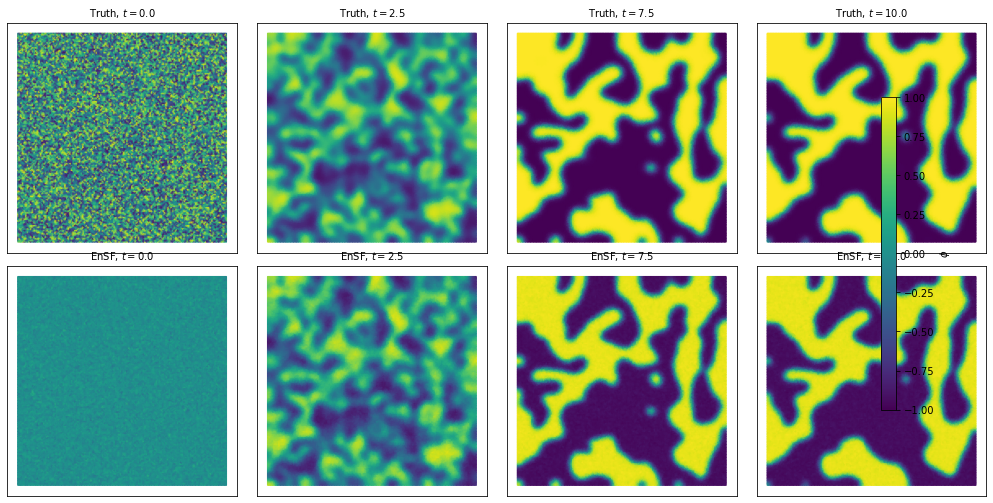

  fig.tight_layout()



Saved: ../figures/ac_obs70_snapshots.pdf


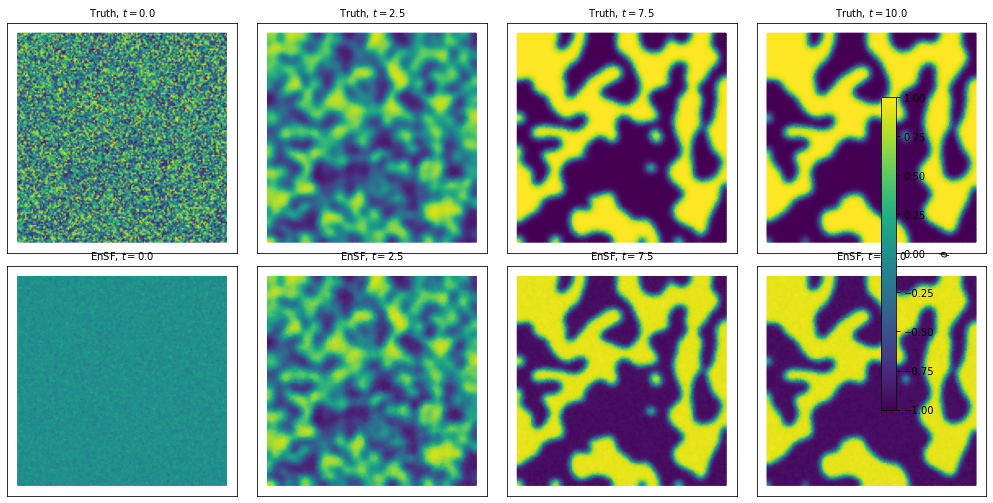

In [5]:
def plot_snapshot_row(res, step_indices, tag):
    n = len(step_indices)
    fig, axes = plt.subplots(2, n, figsize=(3.5 * n, 7))

    for col, k in enumerate(step_indices):
        t_k = t_obs[k]
        tc = plot_field(axes[0, col], X_true[k],
                        title=f"Truth, $t={t_k:.1f}$")
        plot_field(axes[1, col], res["EnSF_est"][k],
                   title=f"EnSF, $t={t_k:.1f}$")

    fig.colorbar(tc, ax=axes, orientation="vertical",
                 fraction=0.02, pad=0.04, label=r"$\phi$")
    fig.tight_layout()
    out = FIGURES_DIR / f"ac_{tag}_snapshots.{FILE_FORMAT}"
    fig.savefig(out, bbox_inches="tight", format=FILE_FORMAT)
    print(f"Saved: {out}")
    plt.show()

steps = [0, 62, 187, 249]
plot_snapshot_row(res100, steps, tag="obs100")
plot_snapshot_row(res70,  steps, tag="obs70")

## Figure 2: RMSE, supremum norm, energy

Saved: ../figures/ac_diagnostics.pdf


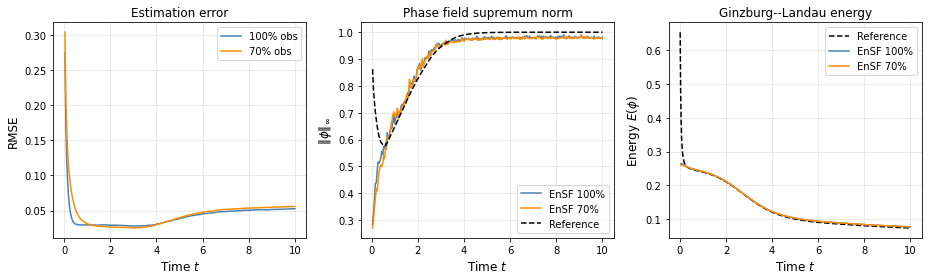

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# RMSE
axes[0].plot(t_obs_filter, res100["step_rmse"],
             label="100% obs", color="steelblue", linewidth=1.5)
axes[0].plot(t_obs_filter, res70["step_rmse"],
             label="70% obs",  color="darkorange", linewidth=1.5)
axes[0].set_xlabel("Time $t$", fontsize=12)
axes[0].set_ylabel("RMSE", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Estimation error")

# Supremum norm
axes[1].plot(t_obs_filter, res100["supnorm_arr"],
             label="EnSF 100%", color="steelblue", linewidth=1.5)
axes[1].plot(t_obs_filter, res70["supnorm_arr"],
             label="EnSF 70%",  color="darkorange", linewidth=1.5)
axes[1].plot(t_obs[1:], supnorm[1:],
             label="Reference", color="k", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Time $t$", fontsize=12)
axes[1].set_ylabel(r"$\|\phi\|_\infty$", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_title("Phase field supremum norm")

# Energy — reference on fine grid, EnSF estimates on obs grid
axes[2].plot(t_fine, energies,
             label="Reference", color="k", linestyle="--", linewidth=1.5)
axes[2].plot(t_obs_filter, res100["energy_arr"],
             label="EnSF 100%", color="steelblue", linewidth=1.5)
axes[2].plot(t_obs_filter, res70["energy_arr"],
             label="EnSF 70%",  color="darkorange", linewidth=1.5)
axes[2].set_xlabel("Time $t$", fontsize=12)
axes[2].set_ylabel("Energy $E(\phi)$", fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_title("Ginzburg--Landau energy")

fig.tight_layout()
out = FIGURES_DIR / f"ac_diagnostics.{FILE_FORMAT}"
fig.savefig(out, bbox_inches="tight", format=FILE_FORMAT)
print(f"Saved: {out}")
plt.show()